# 05b — Event→Event PV-Tendency Projection & Bootstrap Significance

Each blocking event builds **its own orthogonal basis** from its own PV anomaly
fields (`interp_alpha=1` → basis from current dh only, no dh−1 needed),
and each event's tendency terms are projected onto **that event's basis**.
Coefficients are then averaged across events.

This captures nonlinear covariance effects lost by composite-mean projection
(where ⟨T⟩ projected onto ⟨B⟩ ≠ mean of T_i projected onto B_i).

**Level selection**: configurable (wavg or any isobaric level).  
**Parallelism**: 48-worker ThreadPoolExecutor for per-event basis+projection.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os, glob
from concurrent.futures import ThreadPoolExecutor

from pvtend import compute_orthogonal_basis, project_field
from pvtend.decomposition.smoothing import gaussian_smooth_nan

# ═══════════════════════════════════════════════════════════
#  Config flags
# ═══════════════════════════════════════════════════════════
MASK_SPEC = "< -2e-7"   # restrict basis to q' < 0 region (mask)
N_WORKERS       = 48     # parallel workers for per-event projection

## 1  Discover and load all event files

In [2]:
DATA_ROOT  = "/net/flood/data2/users/x_yan/composite_blocking_tempest"
STAGE      = "onset"
DH         = 0
LEVEL      = 250          # "wavg" for mass-weighted vertical avg, or int hPa (e.g. 200, 250, 500)
SMOOTH_DEG = 3.0
GRID_SP    = 1.5

# NOTE: with interp_alpha=1 the basis uses only current-dh fields,
#       so loading dh-1 is unnecessary.  Kept for reference.
# DH_BASIS = max(DH - 1, -13)   # predictive framing (interp_alpha < 1)

# Discover full lifecycle dh range for this stage
_dh_dirs = glob.glob(os.path.join(DATA_ROOT, STAGE, "dh=*"))
DH_RANGE = sorted(int(os.path.basename(d).split("=")[1]) for d in _dh_dirs)

_lvl_str = f"{LEVEL} hPa" if isinstance(LEVEL, (int, float)) else "wavg"

sign = "+" if DH >= 0 else ""
npz_dir = f"{DATA_ROOT}/{STAGE}/dh={sign}{DH}"
npz_files = sorted(glob.glob(os.path.join(npz_dir, "track_*.npz")))

# # dh-1 basis files (not needed when interp_alpha=1)
# sign_b = "+" if DH_BASIS >= 0 else ""
# npz_dir_b = f"{DATA_ROOT}/{STAGE}/dh={sign_b}{DH_BASIS}"
# npz_files_b = sorted(glob.glob(os.path.join(npz_dir_b, "track_*.npz")))

print(f"Stage: {STAGE}   DH={DH} ({len(npz_files)} files)")
print(f"Level: {_lvl_str}   Smoothing: {SMOOTH_DEG}°   Workers: {N_WORKERS}")
print(f"DH_RANGE: {DH_RANGE[0]} … {DH_RANGE[-1]}  ({len(DH_RANGE)} steps)")

Stage: onset   DH=0 (1260 files)
Level: 250 hPa   Smoothing: 3.0°   Workers: 48
DH_RANGE: -13 … 12  (26 steps)


In [3]:
from zipfile import BadZipFile

def load_event(path):
    """Load an NPZ file and return a dict (None if corrupt/incomplete)."""
    try:
        return dict(np.load(path))
    except (BadZipFile, EOFError, OSError):
        return None

def _load_all(file_list, label=""):
    with ThreadPoolExecutor(max_workers=N_WORKERS) as pool:
        results = list(pool.map(load_event, file_list))
    good = [r for r in results if r is not None]
    n_bad = len(results) - len(good)
    if n_bad:
        print(f"  ⚠ {label}: skipped {n_bad} corrupt/incomplete NPZ files")
    return good

def _load_dh(dh, stage=STAGE):
    """Load all events for a given dh."""
    s = "+" if dh >= 0 else ""
    d = f"{DATA_ROOT}/{stage}/dh={s}{dh}"
    files = sorted(glob.glob(os.path.join(d, "track_*.npz")))
    return _load_all(files, f"dh={dh}")

# def _match_events(events_dh, events_prev):
#     """Match events by track_id. Fallback: self-reference if no dh-1 match."""
#     tid_prev = {int(e["track_id"]): e for e in events_prev}
#     pairs, unmatched = [], 0
#     for e in events_dh:
#         tid = int(e["track_id"])
#         if tid in tid_prev:
#             pairs.append((e, tid_prev[tid]))
#         else:
#             pairs.append((e, e))
#             unmatched += 1
#     return pairs, unmatched

# ── Load events at DH ──
events = _load_all(npz_files, f"dh={DH}")

# # dh-1 basis events (not needed when interp_alpha=1)
# events_basis = _load_all(npz_files_b, f"dh={DH_BASIS}")

# ── Grid coordinates ──
X_rel = events[0]["X_rel"]
Y_rel = events[0]["Y_rel"]
x_rel = X_rel[0, :]
y_rel = Y_rel[:, 0]

# ── Level extraction ──
_levels = events[0]["levels"]
if isinstance(LEVEL, (int, float)):
    LEVEL_IDX = int(np.argmin(np.abs(_levels - LEVEL)))
    print(f"LEVEL={LEVEL} hPa → index {LEVEL_IDX} (actual: {_levels[LEVEL_IDX]:.0f} hPa)")
else:
    LEVEL_IDX = None
    print(f"LEVEL=wavg (mass-weighted vertical average)")

def _f(event, name):
    """Extract 2D field at configured LEVEL."""
    if LEVEL == "wavg":
        return event[name]
    key_3d = name + "_3d" if not name.endswith("_3d") else name
    if key_3d in event:
        return event[key_3d][LEVEL_IDX]
    return event[name]  # fallback to wavg if no _3d version

# # Match events by track_id (dh ↔ dh-1) — not needed when interp_alpha=1
# matched_pairs, _unmatched = _match_events(events, events_basis)

print(f"\ndh={DH}: {len(events)} events, shape={events[0]['pv_anom'].shape}")
# print(f"dh={DH_BASIS} (basis): {len(events_basis)} events")
# print(f"Matched pairs: {len(matched_pairs) - _unmatched}/{len(matched_pairs)}"
#       f"  (unmatched fallback: {_unmatched})")

LEVEL=250 hPa → index 6 (actual: 250 hPa)

dh=0: 1260 events, shape=(29, 49)


## 2  Define RHS terms & smoothing helper

In [11]:
smooth = lambda f: gaussian_smooth_nan(f, smoothing_deg=SMOOTH_DEG, grid_spacing=GRID_SP)

# Term name → callable(event_dict) → 2-D field at configured LEVEL
TERMS = {
    r"$\mathrm{d}q/\mathrm{d}t$":  lambda e: _f(e, "pv_anom_dt") + _f(e, "pv_bar_dt"),

    # ── Linear Advection ──
    r"$-\bar{u}_{\psi}\,q'_x$":    lambda e: -_f(e, "u_rot_bar_pv_anom_dx"),
    r"$-v'_{\psi}\bar{q}_y$":      lambda e: -_f(e, "v_rot_anom_pv_bar_dy"),

    # ── Divergence ──
    r"Diabatic Eddy Div $-\mathbf{u'_{\chi, m}}\nabla q'$":  lambda e: -_f(e, "u_div_moist_pv_anom_dx") - _f(e, "v_div_moist_pv_anom_dy"),
    r"Adiabatic Eddy Div $-\mathbf{u'_{\chi, d}}\nabla q'$":    lambda e: -_f(e, "u_div_dry_pv_anom_dx") - _f(e, "v_div_dry_pv_anom_dy"),

    # ── Anom rotational (u'_rot) ──
    r"Eddy Eddy Rot $-\mathbf{u'_{\psi}}\nabla q'$":  lambda e: -_f(e, "u_rot_anom_pv_anom_dx") - _f(e, "v_rot_anom_pv_anom_dy"),

    # ── Vertical ──
    r"$-\omega\,q_p$":  lambda e: -_f(e, "w_moist_pv_bar_dp") - _f(e, "w_moist_pv_anom_dp") - _f(e, "w_dry_pv_bar_dp") - _f(e, "w_dry_pv_anom_dp"),

    # ── Diabatic ──
    r"LHR $Q$":  lambda e: _f(e, "Q"),
}

TERM_NAMES = list(TERMS.keys())
print(f"{len(TERMS)} terms (incl. dq/dt + Q) @ {_lvl_str}:", TERM_NAMES)

8 terms (incl. dq/dt + Q) @ 250 hPa: ['$\\mathrm{d}q/\\mathrm{d}t$', "$-\\bar{u}_{\\psi}\\,q'_x$", "$-v'_{\\psi}\\bar{q}_y$", "Diabatic Eddy Div $-\\mathbf{u'_{\\chi, m}}\\nabla q'$", "Adiabatic Eddy Div $-\\mathbf{u'_{\\chi, d}}\\nabla q'$", "Eddy Eddy Rot $-\\mathbf{u'_{\\psi}}\\nabla q'$", '$-\\omega\\,q_p$', 'LHR $Q$']


## 3  Per-event projection (48 workers)

Each event builds its own orthogonal basis from its own PV fields
(`interp_alpha=1` → current dh only), then projects all tendency terms
onto that basis. Results are collected into per-event coefficient arrays.

In [5]:
def _project_single_event(e_dh):
    """Build per-event basis and project all terms. Returns dict of coefficients."""
    # NOTE: with interp_alpha=1, basis uses only current-dh fields.
    #       Previous-dh fields (e_prev) are not needed.

    pv_anom = _f(e_dh, "pv_anom")
    pv_dx   = _f(e_dh, "pv_dx")
    pv_dy   = _f(e_dh, "pv_dy")

    # # dh-1 fields for predictive framing (not needed when interp_alpha=1)
    # e_prev = pair[1]
    # pv_anom_p = _f(e_prev, "pv_anom")
    # pv_dx_p   = _f(e_prev, "pv_dx")
    # pv_dy_p   = _f(e_prev, "pv_dy")

    try:
        basis_e = compute_orthogonal_basis(
            pv_anom, pv_dx, pv_dy, x_rel, y_rel,
            mask=MASK_SPEC,
            apply_smoothing=True, smoothing_deg=SMOOTH_DEG, grid_spacing=GRID_SP,
            # pv_anom_prev=pv_anom_p, pv_dx_prev=pv_dx_p, pv_dy_prev=pv_dy_p,
            interp_alpha=1,
        )
    except Exception:
        return None  # skip events where basis construction fails

    coefs = {}
    for name, func in TERMS.items():
        fld = func(e_dh)
        fld_s = smooth(fld)
        p = project_field(fld_s, basis_e)
        coefs[name] = {k: p[k] for k in ["beta", "ax", "ay", "gamma"]}
    return coefs

# ── Parallel projection over all events ──
print(f"Projecting {len(events)} events with {N_WORKERS} workers...")
with ThreadPoolExecutor(max_workers=N_WORKERS) as pool:
    results_raw = list(pool.map(_project_single_event, events))

# Filter out failed events
results = [r for r in results_raw if r is not None]
n_failed = len(results_raw) - len(results)
if n_failed:
    print(f"  ⚠ {n_failed} events failed basis construction")
n_events = len(results)

# ── Collect into per-event arrays ──
per_event = {name: {k: np.array([r[name][k] for r in results])
                     for k in ["beta", "ax", "ay", "gamma"]}
             for name in TERM_NAMES}

# ── Print summary ──
print(f"\n{'Term':55s}  {'mean β':>12s}  {'std β':>12s}")
print("─" * 85)
for name in TERM_NAMES:
    arr = per_event[name]["beta"]
    print(f"{name:55s}  {arr.mean():.3e}  {arr.std():.3e}")
print(f"\nN_events={n_events}  Level={_lvl_str}  DH={DH}")

Projecting 1260 events with 48 workers...

Term                                                           mean β         std β
─────────────────────────────────────────────────────────────────────────────────────
$\mathrm{d}q/\mathrm{d}t$                                8.584e-07  2.875e-06
$-\bar{u}_{\psi}\,q'_x$                                  -4.567e-07  2.329e-06
$-v'_{\psi}\bar{q}_y$                                    7.436e-07  2.009e-06
Moist Eddy Div $-\mathbf{u'_{\chi, m}}\nabla q'$         6.935e-07  1.007e-06
Dry Eddy Div $-\mathbf{u'_{\chi, d}}\nabla q'$           3.918e-07  5.277e-07
Eddy Eddy Rot $-\mathbf{u'_{\psi}}\nabla q'$             -8.067e-08  1.627e-06
$-\omega\,q_p$                                           5.486e-07  2.191e-06
$Q$                                                      1.025e-07  8.957e-08

N_events=1260  Level=250 hPa  DH=0


## 4  Bootstrap significance

Resample event indices (with replacement) and compute mean coefficients
for each bootstrap replicate → 95% confidence intervals.

In [6]:
N_BOOT = 1000
rng = np.random.default_rng(42)

# ── Bootstrap: resample event indices, compute mean ──
boot_results = {}
for name in TERM_NAMES:
    boot = {k: np.empty(N_BOOT) for k in ["beta", "ax", "ay", "gamma"]}
    for b in range(N_BOOT):
        idx = rng.integers(0, n_events, size=n_events)
        for k in boot:
            boot[k][b] = per_event[name][k][idx].mean()
    boot_results[name] = boot

    lo, hi = np.nanpercentile(boot["beta"], [2.5, 97.5])
    sig = "***" if lo * hi > 0 else "n.s."
    print(f"  {name:55s}  β 95% CI: [{lo:.3e}, {hi:.3e}]  {sig}")

  $\mathrm{d}q/\mathrm{d}t$                                β 95% CI: [7.075e-07, 1.013e-06]  ***
  $-\bar{u}_{\psi}\,q'_x$                                  β 95% CI: [-5.848e-07, -3.258e-07]  ***
  $-v'_{\psi}\bar{q}_y$                                    β 95% CI: [6.260e-07, 8.622e-07]  ***
  Moist Eddy Div $-\mathbf{u'_{\chi, m}}\nabla q'$         β 95% CI: [6.401e-07, 7.483e-07]  ***
  Dry Eddy Div $-\mathbf{u'_{\chi, d}}\nabla q'$           β 95% CI: [3.630e-07, 4.203e-07]  ***
  Eddy Eddy Rot $-\mathbf{u'_{\psi}}\nabla q'$             β 95% CI: [-1.657e-07, 1.125e-08]  n.s.
  $-\omega\,q_p$                                           β 95% CI: [4.289e-07, 6.721e-07]  ***
  $Q$                                                      β 95% CI: [9.772e-08, 1.073e-07]  ***


## 5  Visualise: bar + asterisk (single dh)

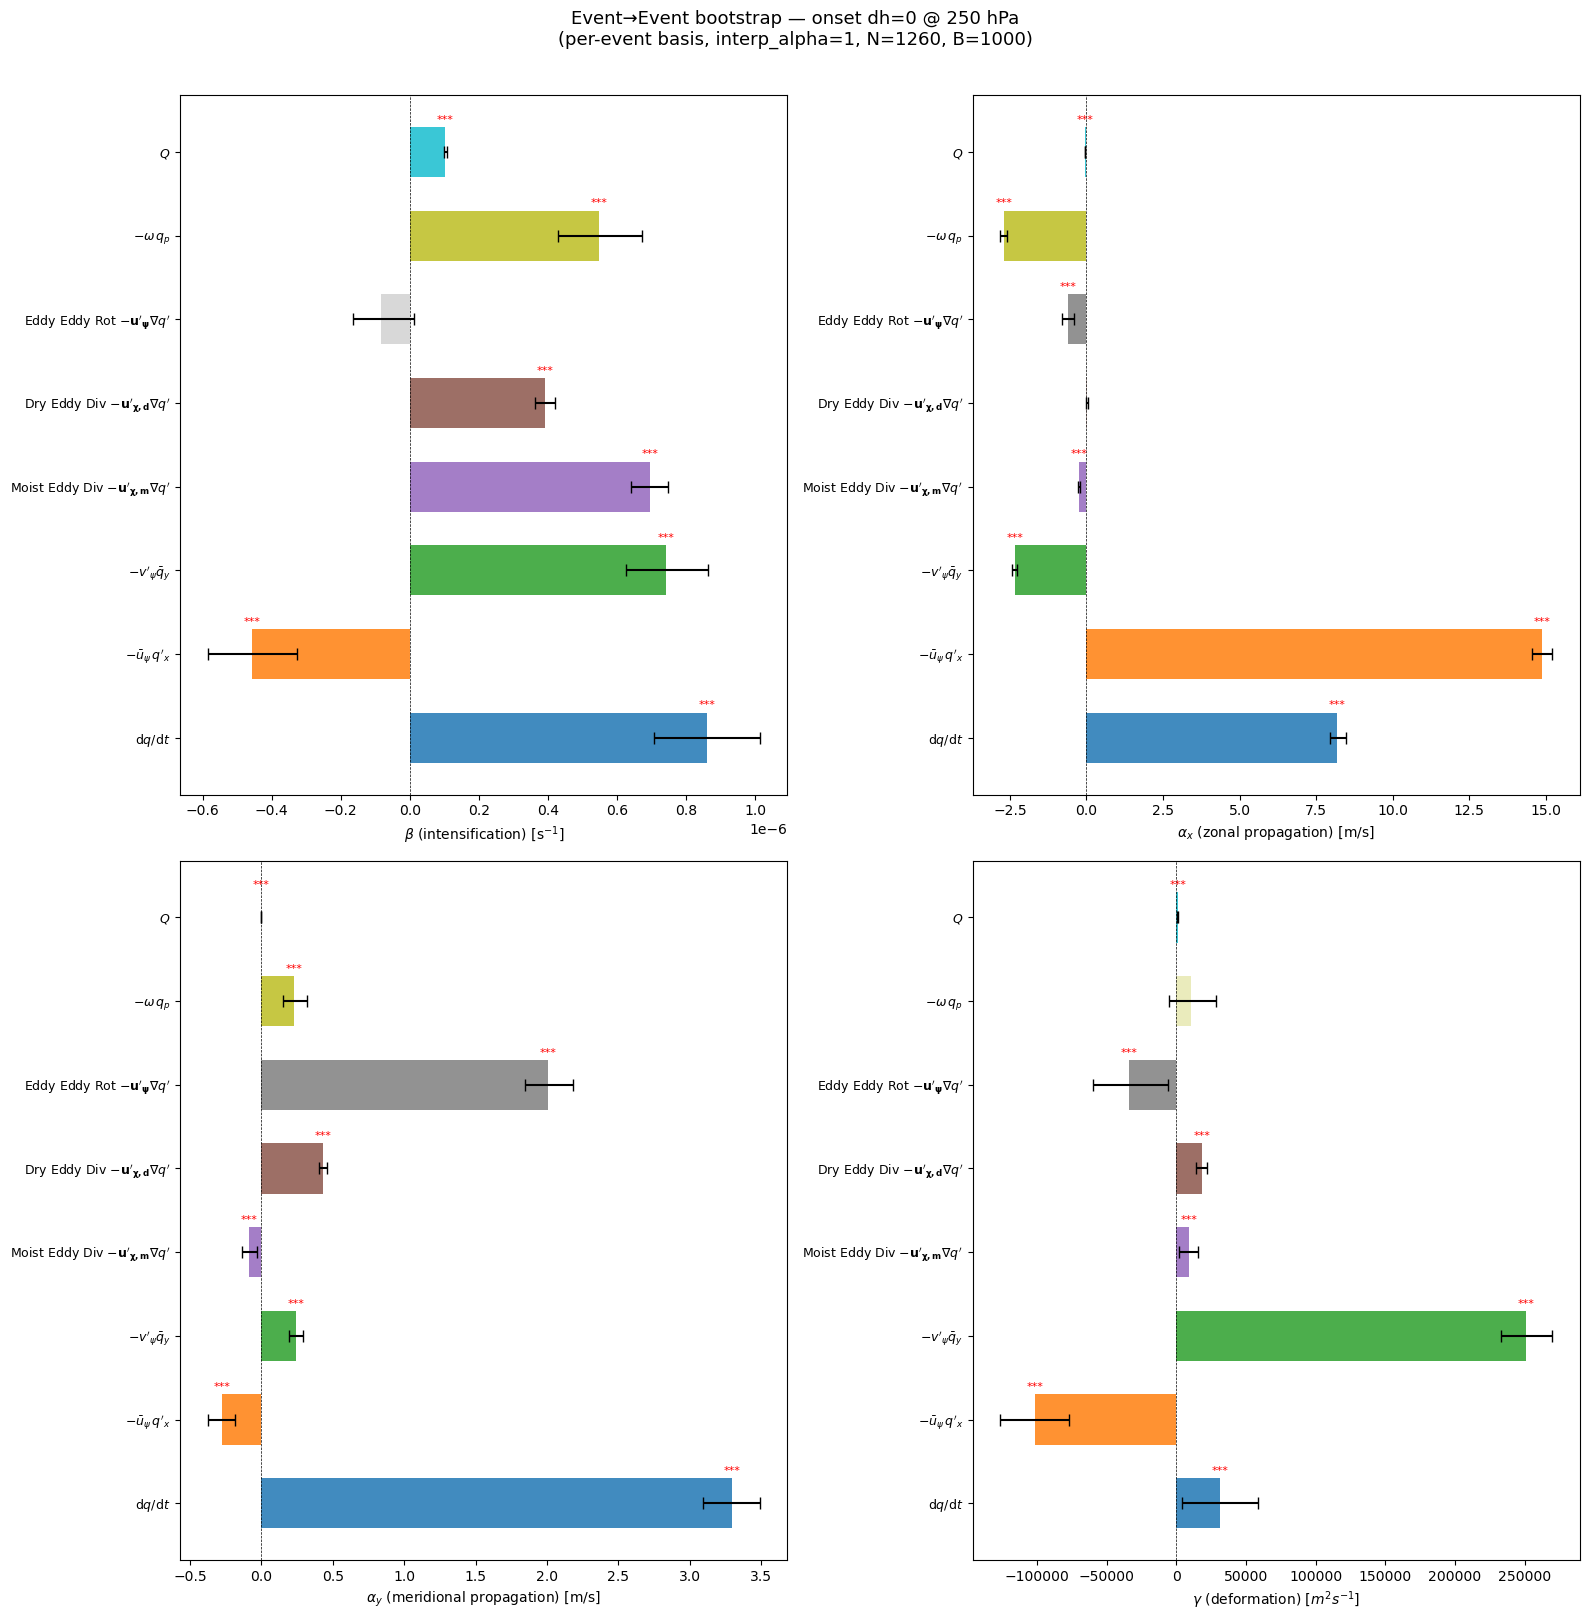

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 16))
coef_names = ["beta", "ax", "ay", "gamma"]
coef_labels = [r"$\beta$ (intensification) [s$^{-1}$]",
               r"$\alpha_x$ (zonal propagation) [m/s]",
               r"$\alpha_y$ (meridional propagation) [m/s]",
               r"$\gamma$ (deformation) [$m^2s^{-1}$]"]

n_terms = len(TERMS)
colors = plt.cm.tab10(np.linspace(0, 1, n_terms))

for ax, cname, clabel in zip(axes.flat, coef_names, coef_labels):
    for i, (tname, bdata) in enumerate(boot_results.items()):
        vals = bdata[cname]
        mean = vals.mean()
        lo, hi = np.nanpercentile(vals, [2.5, 97.5])
        sig = lo * hi > 0  # CI excludes zero?

        ax.barh(i, mean, xerr=[[mean - lo], [hi - mean]],
                color=colors[i],
                alpha=0.85 if sig else 0.3,
                capsize=4, height=0.6)
        if sig:
            ax.text(mean, i + 0.35, "***", ha="center", fontsize=8, color="red")

    ax.set_yticks(range(n_terms))
    ax.set_yticklabels(TERM_NAMES, fontsize=9)
    ax.axvline(0, color="k", lw=0.5, ls="--")
    ax.set_xlabel(clabel, fontsize=10)

fig.suptitle(f"Event→Event bootstrap — {STAGE} dh={DH} @ {_lvl_str}\n"
             f"(per-event basis, interp_alpha=1, N={n_events}, B={N_BOOT})",
             fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

## 6  Lifecycle stacked bar — β budget across all dh

Loop over every lifecycle hour, load events, run per-event
basis+projection in parallel (48 workers), and plot the stacked-bar β budget.
(`interp_alpha=1` → no dh−1 loading needed.)

dh=-13  N=1260  β(dq/dt)=2.046e-07
dh=-12  N=1260  β(dq/dt)=3.217e-07
dh=-11  N=1260  β(dq/dt)=3.487e-07
dh=-10  N=1260  β(dq/dt)=3.390e-07
dh= -9  N=1260  β(dq/dt)=4.064e-07
dh= -8  N=1260  β(dq/dt)=5.074e-07
dh= -7  N=1260  β(dq/dt)=4.959e-07
dh= -6  N=1260  β(dq/dt)=5.292e-07
dh= -5  N=1260  β(dq/dt)=5.241e-07
dh= -4  N=1260  β(dq/dt)=5.736e-07
dh= -3  N=1260  β(dq/dt)=6.954e-07
dh= -2  N=1260  β(dq/dt)=7.327e-07
dh= -1  N=1260  β(dq/dt)=7.954e-07
dh=+  0  N=1260  β(dq/dt)=8.584e-07
dh=+  1  N=1260  β(dq/dt)=8.773e-07
dh=+  2  N=1260  β(dq/dt)=9.562e-07
dh=+  3  N=1260  β(dq/dt)=1.023e-06
dh=+  4  N=1260  β(dq/dt)=1.011e-06
dh=+  5  N=1260  β(dq/dt)=9.668e-07
dh=+  6  N=1260  β(dq/dt)=9.191e-07
dh=+  7  N=1260  β(dq/dt)=8.361e-07
dh=+  8  N=1260  β(dq/dt)=7.811e-07
dh=+  9  N=1260  β(dq/dt)=7.749e-07
dh=+ 10  N=1260  β(dq/dt)=7.720e-07
dh=+ 11  N=1260  β(dq/dt)=7.434e-07
dh=+ 12  N=1260  β(dq/dt)=7.963e-07


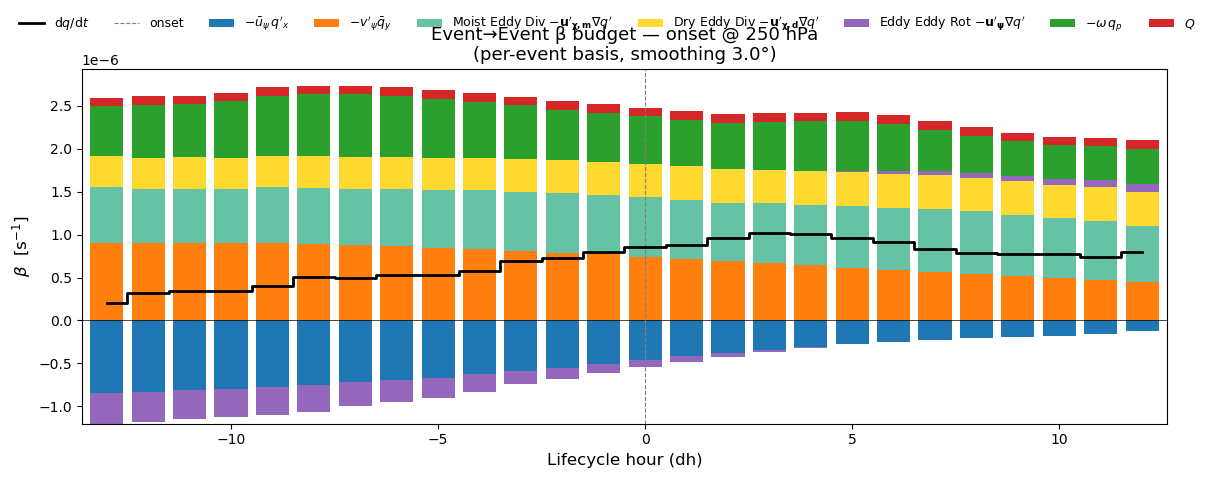

In [8]:
# ═══════════════════════════════════════════════════════════
#  Lifecycle loop — per-event projection at every dh
#  NOTE: interp_alpha=1 → basis from current dh only, no dh-1 needed
# ═══════════════════════════════════════════════════════════

beta_life = {name: [] for name in TERM_NAMES}
beta_life_sem = {name: [] for name in TERM_NAMES}
n_events_life = []

for dh in DH_RANGE:
    # # dh-1 matching (not needed when interp_alpha=1)
    # dh_b = max(dh - 1, DH_RANGE[0])

    evs_dh = _load_dh(dh)
    # evs_prev = _load_dh(dh_b) if dh_b != dh else evs_dh
    # pairs, um = _match_events(evs_dh, evs_prev)

    with ThreadPoolExecutor(max_workers=N_WORKERS) as pool:
        res_raw = list(pool.map(_project_single_event, evs_dh))
    res = [r for r in res_raw if r is not None]
    n_events_life.append(len(res))

    for name in TERM_NAMES:
        arr = np.array([r[name]["beta"] for r in res])
        beta_life[name].append(arr.mean())
        beta_life_sem[name].append(arr.std() / np.sqrt(len(arr)))  # SEM

    s = "+" if dh >= 0 else ""
    print(f"dh={s}{dh:>3d}  N={len(res):4d}  "
          f"β(dq/dt)={beta_life[TERM_NAMES[0]][-1]:.3e}")

dh_arr = np.array(DH_RANGE)
for name in TERM_NAMES:
    beta_life[name] = np.array(beta_life[name])
    beta_life_sem[name] = np.array(beta_life_sem[name])

# ── Stacked bar plot ──
_tab10 = plt.cm.tab10
_set2  = plt.cm.Set2

TERM_COLORS = {
    TERM_NAMES[0]: "black",            # dq/dt  (step line overlay)
    TERM_NAMES[1]: _tab10(0),          # -ū_ψ q'_x   (blue)
    TERM_NAMES[2]: _tab10(1),          # -v'_ψ q̄_y   (orange)
    TERM_NAMES[3]: _set2(0),           # Moist Eddy Div  (teal)
    TERM_NAMES[4]: _set2(5),           # Dry Eddy Div    (gold)
    TERM_NAMES[5]: _tab10(4),          # Eddy Eddy Rot   (purple)
    TERM_NAMES[6]: _tab10(2),          # -ω q_p          (green)
    TERM_NAMES[7]: _tab10(3),          # Q                (red)
}

rhs_names = TERM_NAMES[1:]
fig, ax = plt.subplots(figsize=(14, 5))
bar_width = 0.8

pos_bottom = np.zeros(len(dh_arr))
neg_bottom = np.zeros(len(dh_arr))

for name in rhs_names:
    vals = beta_life[name]
    pos_vals = np.where(vals > 0, vals, 0)
    neg_vals = np.where(vals < 0, vals, 0)

    ax.bar(dh_arr, pos_vals, bottom=pos_bottom, width=bar_width,
           color=TERM_COLORS[name], edgecolor="none", label=name)
    ax.bar(dh_arr, neg_vals, bottom=neg_bottom, width=bar_width,
           color=TERM_COLORS[name], edgecolor="none")

    pos_bottom += pos_vals
    neg_bottom += neg_vals

# Overlay dq/dt as a black step line
ax.step(dh_arr, beta_life[TERM_NAMES[0]], where="mid",
        color="black", lw=2, label=TERM_NAMES[0], zorder=5)

ax.axhline(0, color="k", lw=0.5)
ax.axvline(0, color="grey", lw=0.8, ls="--", label="onset")
ax.set_xlabel("Lifecycle hour (dh)", fontsize=12)
ax.set_ylabel(r"$\beta$  [s$^{-1}$]", fontsize=12)
ax.set_title(f"Event→Event β budget — {STAGE} @ {_lvl_str}\n"
             f"(per-event basis, smoothing {SMOOTH_DEG}°)", fontsize=13)

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center",
           bbox_to_anchor=(0.5, 0.95), ncol=len(labels),
           fontsize=9, frameon=False)

ax.set_xlim(dh_arr[0] - 0.6, dh_arr[-1] + 0.6)
fig.subplots_adjust(top=0.82)
plt.show()

## Summary

- **Event→Event projection**: each blocking event builds its own orthogonal basis
  from its own PV anomaly fields (`interp_alpha=1` → current dh only), and projects
  its own tendency terms onto that basis. Coefficients are averaged across events.
- **Level selection**: configurable (`LEVEL = 250` hPa or `"wavg"`).
- **8 terms**: dq/dt + 2 linear advection + 2 divergent eddy + 1 rotational eddy + 1 vertical + Q.
- **48-worker ThreadPoolExecutor** for parallel per-event basis construction + projection.
- **Bootstrap resampling** (N=1000) provides 95% CIs; bars are opaque when CI excludes zero.
- **Lifecycle stacked bar**: mean β per term across all dh steps.
- **Data**: `composite_blocking_tempest/{STAGE}`.

## 7  Closure check: full advection budget (Helmholtz-partitioned)

Verify that the **20 rot/div-partitioned advection cross-terms** (5 wind groups × 4
bar/anom combinations) plus diabatic heating $Q$ close the PV budget:

$$
\underbrace{\frac{\partial q'}{\partial t}
+ \frac{\partial \bar{q}}{\partial t}}_{\text{LHS (tendency)}}
\;\approx\;
\underbrace{-\sum_{\substack{\psi/\chi \\ \text{bar/anom}}}
\mathbf{u}_i \cdot \nabla q_j
\;-\; \omega_k \frac{\partial q_j}{\partial p}
\;+\; Q}_{\text{RHS (20 advection + Q)}}
$$

**5 wind groups**: $\bar{u}_\psi$, $\bar{u}_\chi$, $u'_\psi$, $u'_\chi$, $\omega$ (bar+anom).
Each × 4 PV gradient combos (bar/anom × zonal/merid or bar/anom × vert) = **20 terms**.

Residual = LHS − RHS is bootstrapped; dots mark grid points where
the 1.5 σ CI on the residual **excludes zero** (significant imbalance).

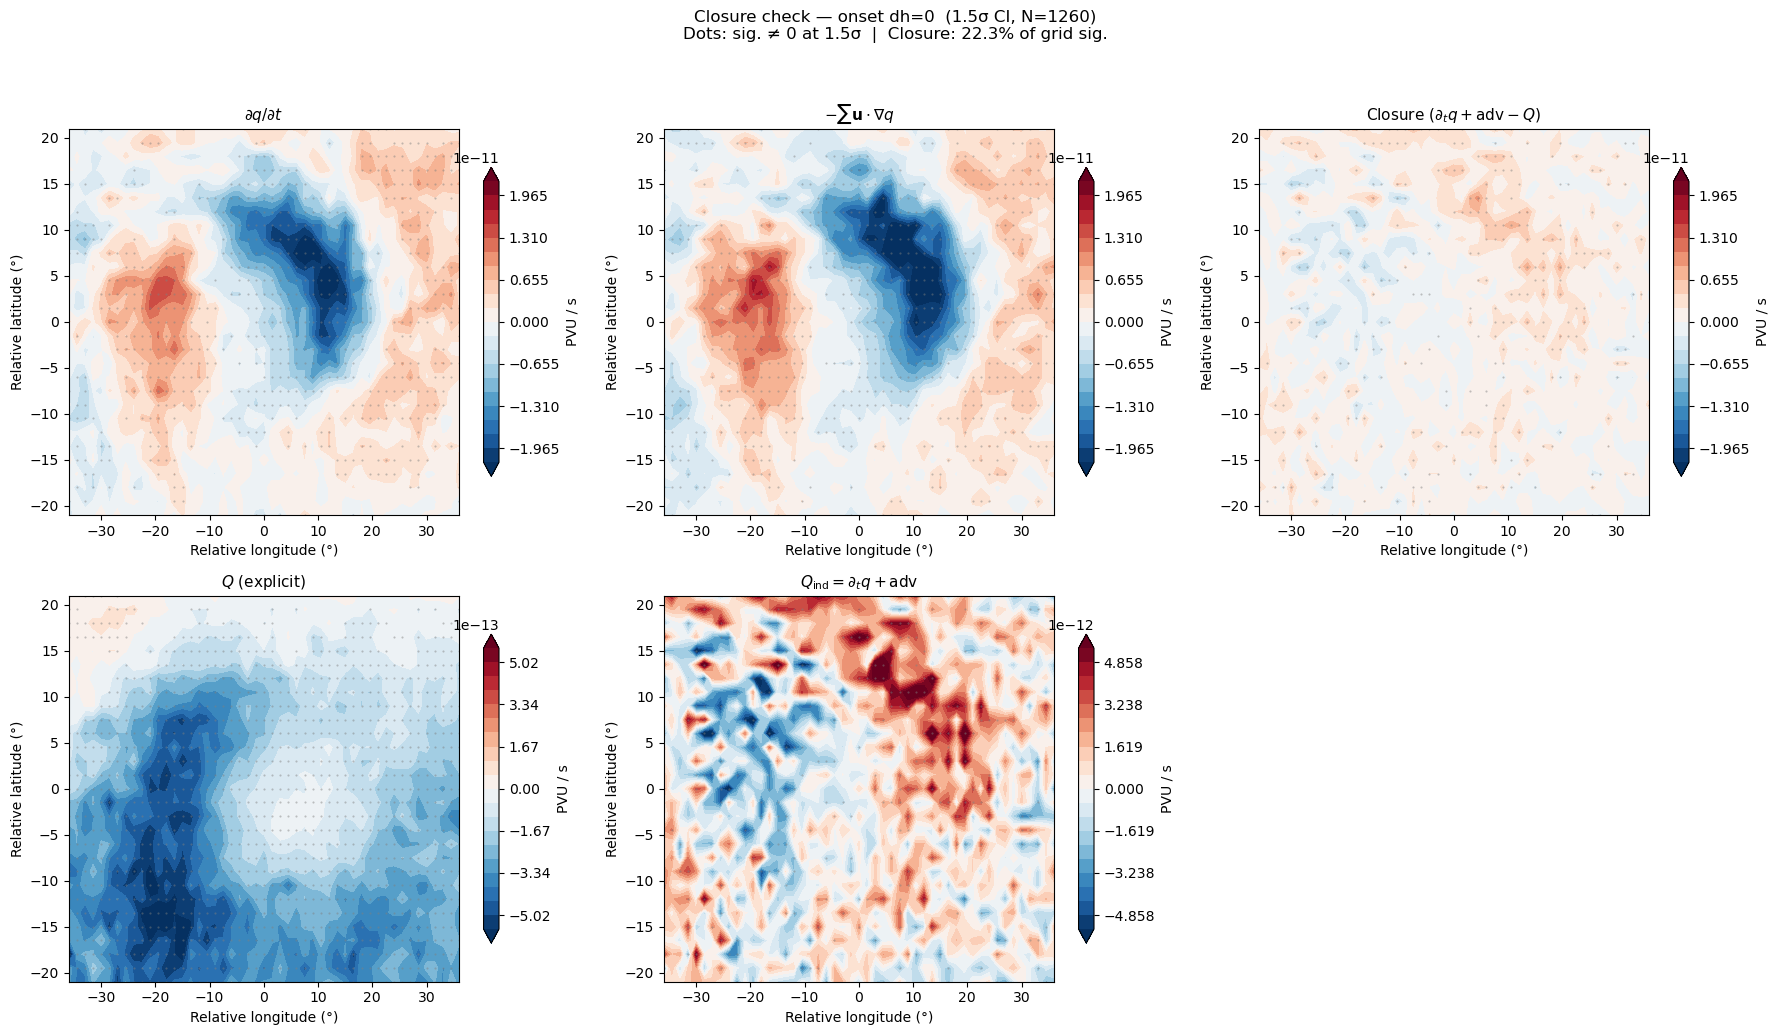

Grid points with sig. imbalance (1.5σ): 317/1421 (22.3%)
Mean |dq/dt|:     4.457e-12
Mean |residual|:  1.696e-12
Mean |rel. res|:  189.4%


In [9]:

# ── All 20 Helmholtz-partitioned advection cross-terms ──
# 5 wind groups × 4 bar/anom cross-terms = 20
# u_bar = u_rot_bar + u_div_bar;  u_anom = u_anom_rot + u_anom_div
# so the sum of these 20 ≡ the original 12 base terms.
ADV_KEYS = [
    # Clim rotational  (ū_ψ)
    "u_rot_bar_pv_bar_dx",   "u_rot_bar_pv_anom_dx",
    "v_rot_bar_pv_bar_dy",   "v_rot_bar_pv_anom_dy",
    # Clim divergent   (ū_χ)
    "u_div_bar_pv_bar_dx",   "u_div_bar_pv_anom_dx",
    "v_div_bar_pv_bar_dy",   "v_div_bar_pv_anom_dy",
    # Anom rotational  (u'_ψ)
    "u_rot_anom_pv_bar_dx",  "u_rot_anom_pv_anom_dx",
    "v_rot_anom_pv_bar_dy",  "v_rot_anom_pv_anom_dy",
    # Anom divergent   (u'_χ)
    "u_div_anom_pv_bar_dx",  "u_div_anom_pv_anom_dx",
    "v_div_anom_pv_bar_dy",  "v_div_anom_pv_anom_dy",
    # Vertical (ω bar + anom)
    "w_bar_pv_bar_dp",       "w_bar_pv_anom_dp",
    "w_anom_pv_bar_dp",      "w_anom_pv_anom_dp",
]

def _lhs(e):
    """LHS = dq'/dt + dq̄/dt."""
    return e["pv_anom_dt"] + e["pv_bar_dt"]

def _neg_adv(e):
    """Negated sum of 20 Helmholtz-partitioned advection cross-terms."""
    return -sum(e[k] for k in ADV_KEYS)

def _Q(e):
    return e["Q"]

def _Q_induced(e):
    """Closure-induced Q = dq/dt + Σ(adv)."""
    return _lhs(e) + sum(e[k] for k in ADV_KEYS)

def _residual(e):
    """Closure residual = dq/dt + Σ(adv) − Q."""
    return _lhs(e) + sum(e[k] for k in ADV_KEYS) - e["Q"]

# ── Bootstrap all five fields ──
from scipy.stats import norm

N_BOOT_CL = 1000
rng_cl = np.random.default_rng(99)
n_ev = len(events)

panel_funcs = {
    r"$\partial q/\partial t$": _lhs,
    r"$-\sum \mathbf{u}\cdot\nabla q$": _neg_adv,
    r"Closure ($\partial_t q + \mathrm{adv} - Q$)": _residual,
    r"$Q$ (explicit)": _Q,
    r"$Q_{\mathrm{ind}} = \partial_t q + \mathrm{adv}$": _Q_induced,
}

p_lo = norm.cdf(-1.5) * 100  # ≈ 6.68
p_hi = norm.cdf( 1.5) * 100  # ≈ 93.32

panel_data = {}  # name → (mean, sig_mask)
for name, func in panel_funcs.items():
    stack = np.array([func(e) for e in events])
    mean = np.nanmean(stack, axis=0)
    boot = np.empty((N_BOOT_CL, *mean.shape))
    for b in range(N_BOOT_CL):
        idx = rng_cl.integers(0, n_ev, size=n_ev)
        boot[b] = np.nanmean(stack[idx], axis=0)
    ci_lo = np.nanpercentile(boot, p_lo, axis=0)
    ci_hi = np.nanpercentile(boot, p_hi, axis=0)
    sig = ~((ci_lo <= 0) & (ci_hi >= 0))
    panel_data[name] = (mean, sig)

panel_names = list(panel_funcs.keys())

# ── Colour scales ──
# Row 0: dq/dt, -adv, Closure → shared scale
row0_names = [panel_names[0], panel_names[1], panel_names[2]]
# Row 1: Q, Q_ind → each gets its own scale
q_name    = panel_names[3]
qind_name = panel_names[4]

vmax_row0 = max(np.nanpercentile(np.abs(panel_data[n][0]), 98)
                for n in row0_names)
vmax_Q    = np.nanpercentile(np.abs(panel_data[q_name][0]), 98)
vmax_Qind = np.nanpercentile(np.abs(panel_data[qind_name][0]), 98)

N_LEV = 21
levs_row0 = np.linspace(-vmax_row0, vmax_row0, N_LEV)
levs_Q    = np.linspace(-vmax_Q, vmax_Q, N_LEV)
levs_Qind = np.linspace(-vmax_Qind, vmax_Qind, N_LEV)

# ── Plot 2×3 ──
# Row 0: dq/dt | -Σadv | Closure   (shared cbar)
# Row 1: Q     | Q_ind             (each own cbar)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

plot_layout = [
    (0, 0, panel_names[0], levs_row0),   # dq/dt
    (0, 1, panel_names[1], levs_row0),   # -Σadv
    (0, 2, panel_names[2], levs_row0),   # Closure
    (1, 0, panel_names[3], levs_Q),      # Q explicit
    (1, 1, panel_names[4], levs_Qind),   # Q_induced
]

for row, col, name, levs in plot_layout:
    ax = axes[row, col]
    mean, sig = panel_data[name]
    cf = ax.contourf(X_rel, Y_rel, mean, levels=levs,
                     cmap="RdBu_r", extend="both")
    if sig.any():
        ax.plot(X_rel[sig], Y_rel[sig], '.', color='grey',
                markersize=1.0, alpha=0.5)
    plt.colorbar(cf, ax=ax, shrink=0.8, label="PVU / s")
    ax.set_title(name, fontsize=11)
    ax.set_xlabel("Relative longitude (°)")
    ax.set_ylabel("Relative latitude (°)")

axes[1, 2].set_visible(False)

lhs_mean = panel_data[panel_names[0]][0]
res_name = panel_names[2]  # Closure
res_mean, res_sig = panel_data[res_name]
frac_sig = res_sig.sum() / res_sig.size * 100
fig.suptitle(f"Closure check — {STAGE} dh={DH}  (1.5σ CI, N={n_ev})\n"
             f"Dots: sig. ≠ 0 at 1.5σ  |  Closure: {frac_sig:.1f}% of grid sig.",
             fontsize=12, y=1.03)
fig.tight_layout()
plt.show()

print(f"Grid points with sig. imbalance (1.5σ): "
      f"{res_sig.sum()}/{res_sig.size} ({frac_sig:.1f}%)")
print(f"Mean |dq/dt|:     {np.nanmean(np.abs(lhs_mean)):.3e}")
print(f"Mean |residual|:  {np.nanmean(np.abs(res_mean)):.3e}")
print(f"Mean |rel. res|:  {np.nanmean(np.abs(res_mean / (np.abs(lhs_mean) + 1e-30))) * 100:.1f}%")
